In [97]:
import os
from functools import reduce

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import seaborn as sns
import matplotlib.dates as mdates

data_path = "data"

# Tratando os dados

In [98]:
dfs = []
for file in os.listdir(data_path):
    if file.endswith(".csv"):
        print(file)
        df = pd.read_csv(os.path.join(data_path, file))
        df['Date'] = pd.to_datetime(df['YYYYMM'], format='%Y%m', errors='coerce')
        df = df.drop(columns=['YYYYMM'])
        df = df.dropna(subset=['Date'])
        dfs.append([file, df])

Average_prices_of_electricity_to_ultimate_customers.csv
Cooling_degree_days_by_census_division.csv
Heating_degree_days_by_census_division.csv
Residential_sector_energy_consumption.csv


### Average prices of electricity to ultimate customers

In [99]:
dfs[0][1].head()

,MSN,Value,Column_Order,Description,Unit,Date
16,ESRCUUS,Not Available,1,Average Price of Electricity to Ultimate Custo...,"Cents per Kilowatthour, Including Taxes",1976-01-01
17,ESRCUUS,Not Available,1,Average Price of Electricity to Ultimate Custo...,"Cents per Kilowatthour, Including Taxes",1976-02-01
18,ESRCUUS,Not Available,1,Average Price of Electricity to Ultimate Custo...,"Cents per Kilowatthour, Including Taxes",1976-03-01
19,ESRCUUS,Not Available,1,Average Price of Electricity to Ultimate Custo...,"Cents per Kilowatthour, Including Taxes",1976-04-01
20,ESRCUUS,Not Available,1,Average Price of Electricity to Ultimate Custo...,"Cents per Kilowatthour, Including Taxes",1976-05-01


In [100]:
# MSN significa "Mnemonic series names"
# MSN "ESRCUUS" significa setor residencial, que é o que estamos interessados
dfs[0][1] = dfs[0][1][dfs[0][1]["MSN"] == "ESRCUUS"]
# Selecionamos apenas as duas colunas de interesse
# Value (preço médio da eletricidade) e Date (data da medição)
dfs[0][1] = dfs[0][1][["Value", "Date"]].rename(columns={"Value": "Price"})
len(dfs[0][1])

603

### Cooling degree days (CDD) by census division

In [101]:
dfs[1][1].head()

,MSN,Value,Column_Order,Description,Unit,Date
24,ZWCDPC1,0,1,"Cooling Degree-Days, New England",Number,1973-01-01
25,ZWCDPC1,0,1,"Cooling Degree-Days, New England",Number,1973-02-01
26,ZWCDPC1,0,1,"Cooling Degree-Days, New England",Number,1973-03-01
27,ZWCDPC1,0,1,"Cooling Degree-Days, New England",Number,1973-04-01
28,ZWCDPC1,0,1,"Cooling Degree-Days, New England",Number,1973-05-01


In [102]:
# Queremos pegar todos os MSN, pois todos representam o setor residencial nessa tabela.
# Criamos uma coluna "Region", que captura apenas a região para o valor de CDD
dfs[1][1]["Region"] = dfs[1][1]["Description"].str.split(", ").str[1]
# Selecionamos apenas as colunas de interesse, que são Value (Cooling Degree Days), Date e Region
dfs[1][1] = dfs[1][1][["Value", "Date", "Region"]].rename(columns={"Value": "Cooling Degree Days"})
len(dfs[1][1])

6410

### Heating degree days (HDD) by census division

In [103]:
dfs[2][1].head()

,MSN,Value,Column_Order,Description,Unit,Date
24,ZWHDPC1,1171,1,"Heating Degree-Days, New England",Number,1973-01-01
25,ZWHDPC1,1109,1,"Heating Degree-Days, New England",Number,1973-02-01
26,ZWHDPC1,773,1,"Heating Degree-Days, New England",Number,1973-03-01
27,ZWHDPC1,536,1,"Heating Degree-Days, New England",Number,1973-04-01
28,ZWHDPC1,340,1,"Heating Degree-Days, New England",Number,1973-05-01


In [104]:
# Queremos pegar todos os MSN, pois todos representam o setor residencial nessa tabela.
# Criamos uma coluna "Region", que captura apenas a região para o valor de HDD
dfs[2][1]["Region"] = dfs[2][1]["Description"].str.split(", ").str[1]
    
dfs[2][1] = dfs[2][1][["Value", "Date", "Region"]].rename(columns={"Value": "Heating Degree Days"})
len(dfs[2][1])

6410

### Residential sector energy consumption

In [105]:
dfs[3][1].head()

,MSN,Value,Column_Order,Description,Unit,Date
24,CLRCBUS,11.894,1,Coal Consumed by the Residential Sector,Trillion Btu,1973-01-01
25,CLRCBUS,10.188,1,Coal Consumed by the Residential Sector,Trillion Btu,1973-02-01
26,CLRCBUS,8,1,Coal Consumed by the Residential Sector,Trillion Btu,1973-03-01
27,CLRCBUS,5.237,1,Coal Consumed by the Residential Sector,Trillion Btu,1973-04-01
28,CLRCBUS,5.313,1,Coal Consumed by the Residential Sector,Trillion Btu,1973-05-01


In [106]:
# Queremos pegar apenas o consumo total de energia.
dfs[3][1] = dfs[3][1][dfs[3][1]["Description"].str.contains("Total Energy Consumed by the Residential Sector")]
# Selecionamos apenas as colunas de interesse, que são Value (Total Energy Consumption), Description e Date
dfs[3][1] = dfs[3][1][["Value", "Description", "Date"]].rename(columns={"Value": "Total Energy Consumption"})
len(dfs[3][1])

639

### Merge de todas as tabelas por data

In [107]:
df = dfs[0][1].merge(dfs[1][1], on="Date", how="inner").merge(dfs[2][1], on=["Date", "Region"], how="inner").merge(dfs[3][1], on="Date", how="inner")
len(df)

6030

In [108]:
df.head()

,Price,Date,Cooling Degree Days,Region,Heating Degree Days,Total Energy Consumption,Description
0,Not Available,1976-01-01,0,New England,1397,1943.925,Total Energy Consumed by the Residential Sector
1,Not Available,1976-01-01,0,Middle Atlantic,1327,1943.925,Total Energy Consumed by the Residential Sector
2,Not Available,1976-01-01,0,East North Central,1410,1943.925,Total Energy Consumed by the Residential Sector
3,Not Available,1976-01-01,0,West North Central,1387,1943.925,Total Energy Consumed by the Residential Sector
4,Not Available,1976-01-01,11,South Atlantic,779,1943.925,Total Energy Consumed by the Residential Sector


### Reformulação da tabela

Para uma melhor formatação, criamos colunas representando cada região, ao invés de se apoiar no formato de linhas. Podemos pensar em uma "transposição" da matriz de dados.

In [109]:
# Renomeamos as colunas longas para as siglas para melhor leitura
df = df.rename(columns={
    'Cooling Degree Days': 'CDD',
    'Heating Degree Days': 'HDD'
})

#Definimos quais colunas vão identificar nossa "linha única"
base = ['Date', 'Price', 'Total Energy Consumption']

# Fazemos o pivot (agora usando os nomes curtos 'CDD' e 'HDD')
df_pivotado = df.pivot_table(
    index=base,
    columns='Region',
    values=['CDD', 'HDD']
)

# Juntamos os dois níveis (isso vai gerar nomes como 'CDD New England')
df_pivotado.columns = [f"{variavel} {regiao}" for variavel, regiao in df_pivotado.columns]

# Resetamos o índice para transformar a Date e as outras bases de volta em colunas
df_final = df_pivotado.reset_index()

# Repare que agora cada linha é única e tem todas as informações relevantes: 
# Data, Preço, CDD para cada região, HDD para cada região e o consumo total de energia.
df_final.head()

,Date,Price,Total Energy Consumption,CDD East North Central,CDD East South Central,CDD Middle Atlantic,CDD Mountain,CDD New England,CDD Pacific,CDD South Atlantic,...,HDD East North Central,HDD East South Central,HDD Middle Atlantic,HDD Mountain,HDD New England,HDD Pacific,HDD South Atlantic,HDD United States,HDD West North Central,HDD West South Central
0,1976-01-01,Not Available,1943.925,0.0,2.0,0.0,0.0,0.0,8.0,11.0,...,1410.0,911.0,1327.0,1005.0,1397.0,575.0,779.0,1050.0,1387.0,616.0
1,1976-02-01,Not Available,1626.369,0.0,10.0,0.0,3.0,0.0,6.0,22.0,...,886.0,461.0,856.0,732.0,950.0,521.0,416.0,661.0,851.0,269.0
2,1976-03-01,Not Available,1388.038,3.0,29.0,0.0,4.0,0.0,8.0,58.0,...,739.0,350.0,764.0,805.0,896.0,542.0,319.0,593.0,836.0,234.0
3,1976-04-01,Not Available,1112.625,1.0,27.0,0.0,16.0,0.0,10.0,54.0,...,447.0,202.0,435.0,494.0,483.0,438.0,172.0,346.0,380.0,77.0
4,1976-05-01,Not Available,949.961,21.0,59.0,9.0,86.0,1.0,43.0,123.0,...,302.0,130.0,274.0,259.0,307.0,199.0,90.0,206.0,252.0,40.0


In [110]:
# Vendo o tamanho do dataframe
len(df_final)

603

### Limpando dados ausentes

Há valores de preço que não estão disponíveis, majoritariamente para datas mais antigas.
É necessário excluir as linhas que não possuem essa informação, já que ela é parte do nosso conjunto de features.

In [111]:
df_final['Date'] = pd.to_datetime(df_final['Date'])
df_final.set_index('Date', inplace=True)

# O coerce transforma strings inválidas em NaN (Not a Number)
df_final['Price'] = pd.to_numeric(df_final['Price'], errors='coerce')
df_final = df_final.dropna(subset=['Price'])

df_final['Total Energy Consumption'] = pd.to_numeric(df_final['Total Energy Consumption'], errors='coerce')
df_final = df_final.dropna(subset=['Total Energy Consumption'])

df_final.head()

,Price,Total Energy Consumption,CDD East North Central,CDD East South Central,CDD Middle Atlantic,CDD Mountain,CDD New England,CDD Pacific,CDD South Atlantic,CDD United States,...,HDD East North Central,HDD East South Central,HDD Middle Atlantic,HDD Mountain,HDD New England,HDD Pacific,HDD South Atlantic,HDD United States,HDD West North Central,HDD West South Central
Date,,,,,,,,,,,,,,,,,,,,,
1976-07-01,3.9,927.179,224.0,344.0,157.0,290.0,129.0,181.0,361.0,264.0,...,8.0,1.0,14.0,21.0,19.0,27.0,1.0,10.0,8.0,0.0
1976-08-01,3.7,923.880,133.0,295.0,148.0,216.0,109.0,122.0,321.0,222.0,...,39.0,3.0,23.0,56.0,33.0,48.0,3.0,24.0,18.0,0.0
1976-09-01,3.8,859.374,29.0,150.0,27.0,114.0,8.0,103.0,193.0,107.0,...,156.0,46.0,140.0,155.0,183.0,64.0,34.0,99.0,124.0,9.0
1976-10-01,3.9,956.327,0.0,10.0,0.0,28.0,0.0,42.0,58.0,20.0,...,586.0,342.0,528.0,477.0,555.0,197.0,274.0,413.0,581.0,209.0
1976-11-01,3.8,1338.986,0.0,0.0,0.0,5.0,0.0,15.0,24.0,6.0,...,1002.0,700.0,866.0,728.0,878.0,351.0,546.0,729.0,1023.0,501.0


In [112]:
# Conferindo o tamanho final do dado
len(df_final)

525

# Análise exploratória

In [113]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,525.0,10.034781,3.306522,3.600,8.010,9.030,12.480,18.83
Total Energy Consumption,525.0,1536.952596,391.219548,859.374,1252.906,1454.471,1782.244,2698.21
CDD East North Central,525.0,62.398095,92.284469,0.000,0.000,2.000,115.000,410.00
CDD East South Central,525.0,135.304762,158.309842,0.000,6.000,43.000,267.000,555.00
CDD Middle Atlantic,525.0,56.710476,91.373217,0.000,0.000,0.000,87.000,364.00
CDD Mountain,525.0,113.691429,132.887343,0.000,3.000,46.000,210.000,464.00
CDD New England,525.0,39.638095,71.587336,0.000,0.000,0.000,47.000,303.00
CDD Pacific,525.0,71.165714,82.600605,5.000,9.000,24.000,122.000,330.00
CDD South Atlantic,525.0,172.314286,152.705819,3.000,44.000,102.000,296.000,519.00
CDD United States,525.0,109.344762,119.443546,2.000,13.000,46.000,198.000,405.00


In [114]:
# Conferindo se não há nenhum valor ausente no dataset final 

missing = df_final.isna().sum()
missing_pct = (missing / len(df_final) * 100).round(2)
missing_summary = pd.DataFrame({'Valores Ausentes': missing, '% do Total': missing_pct})
missing_summary = missing_summary[missing_summary['Valores Ausentes'] > 0].sort_values('% do Total', ascending=False)

if missing_summary.empty:
    print("Nenhum valor ausente encontrado no dataset consolidado.")
else:
    print(missing_summary)

Nenhum valor ausente encontrado no dataset consolidado.


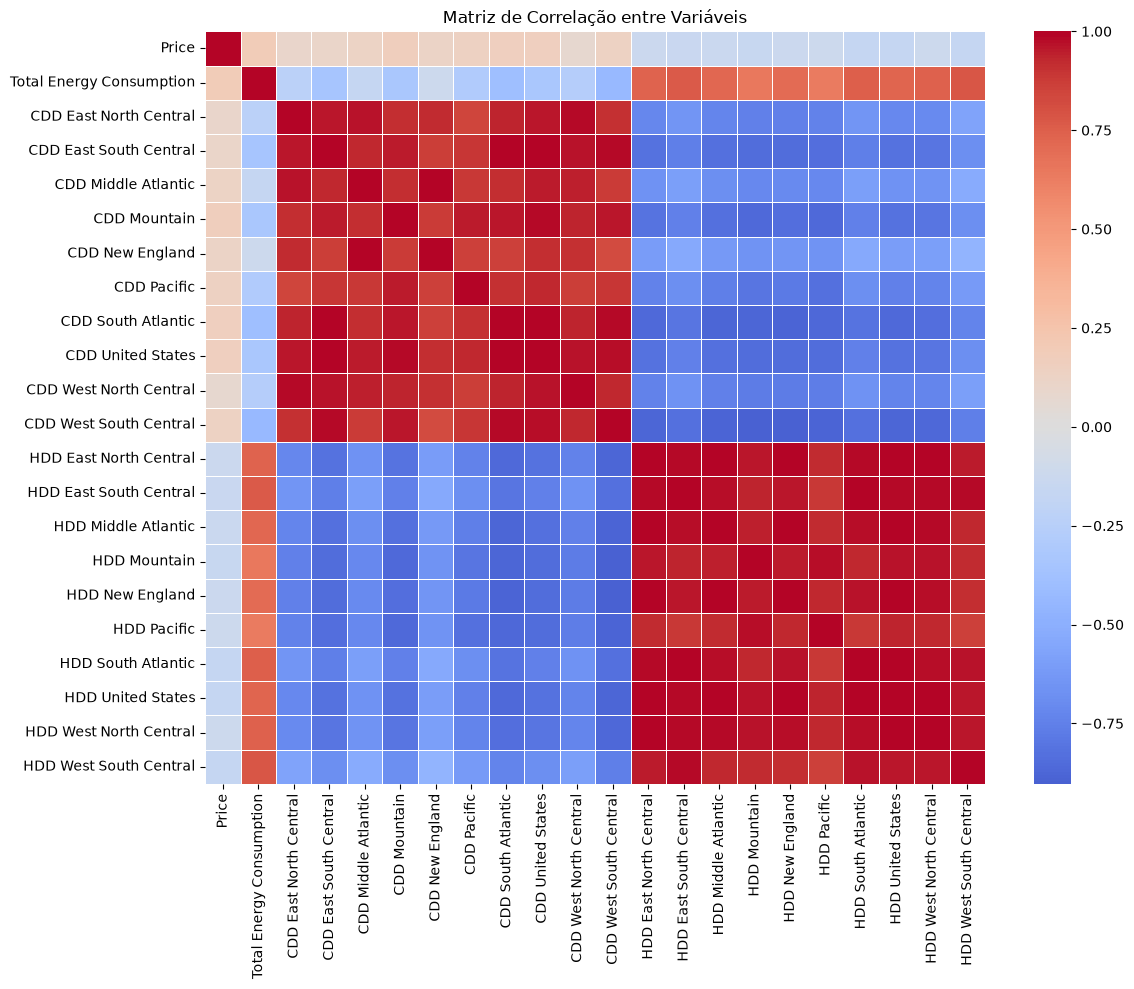

Correlação de cada variável com 'Total Energy Consumption':
HDD West South Central    0.777962
HDD East South Central    0.763947
HDD South Atlantic        0.751795
HDD West North Central    0.740974
HDD East North Central    0.734512
HDD United States         0.725076
HDD Middle Atlantic       0.722436
HDD New England           0.707248
HDD Mountain              0.649597
HDD Pacific               0.629653
CDD West South Central   -0.434444
CDD South Atlantic       -0.394280
CDD East South Central   -0.347375
CDD United States        -0.325331
CDD Mountain             -0.324880
CDD Pacific              -0.288547
CDD West North Central   -0.266078
CDD East North Central   -0.232510
Price                     0.189950
CDD Middle Atlantic      -0.167740
CDD New England          -0.120171
Name: Total Energy Consumption, dtype: float64


In [115]:
# Matriz de correlação entre as variáveis numéricas
corr = df_final.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlação entre Variáveis')
plt.tight_layout()
plt.show()

# Correlações mais fortes (em módulo) com a variável-alvo
target_corr = corr['Total Energy Consumption'].drop('Total Energy Consumption').sort_values(key=abs, ascending=False)
print("Correlação de cada variável com 'Total Energy Consumption':")
print(target_corr)

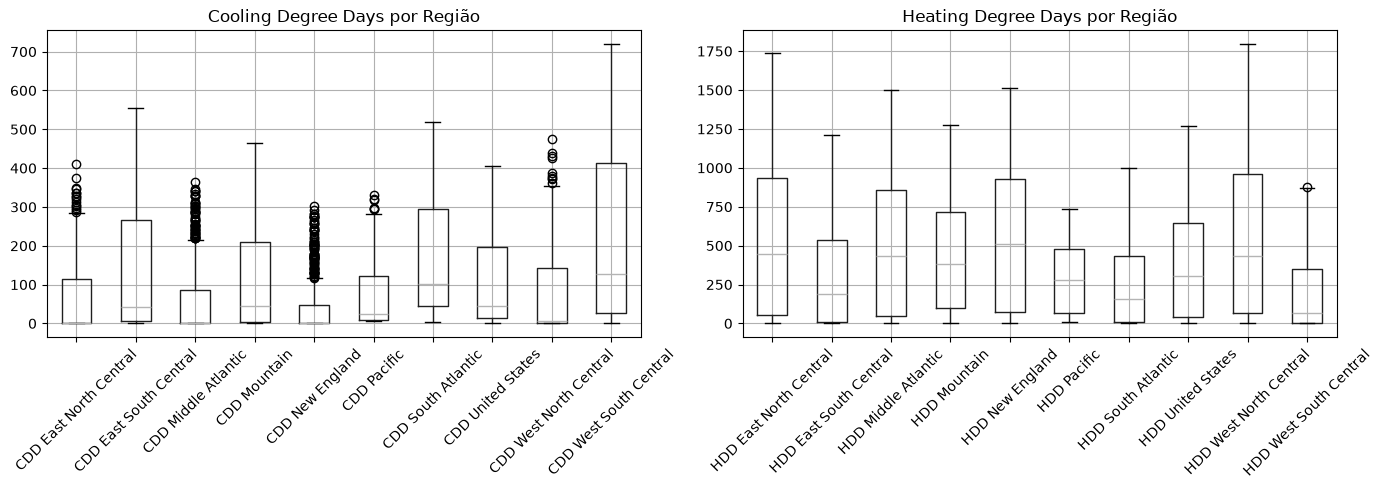

In [116]:
# Distribuição das colunas de CDD e HDD por região (para ver se há regiões com padrões muito diferentes)
cdd_cols = [c for c in df_final.columns if c.startswith('CDD')]
hdd_cols = [c for c in df_final.columns if c.startswith('HDD')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_final[cdd_cols].boxplot(ax=axes[0], rot=45)
axes[0].set_title('Cooling Degree Days por Região')

df_final[hdd_cols].boxplot(ax=axes[1], rot=45)
axes[1].set_title('Heating Degree Days por Região')

plt.tight_layout()
plt.show()

### Preço e consumo de energia ao longo do tempo.

Repare que há um "gap" na década de 80, identificado e tratado posteriormente.

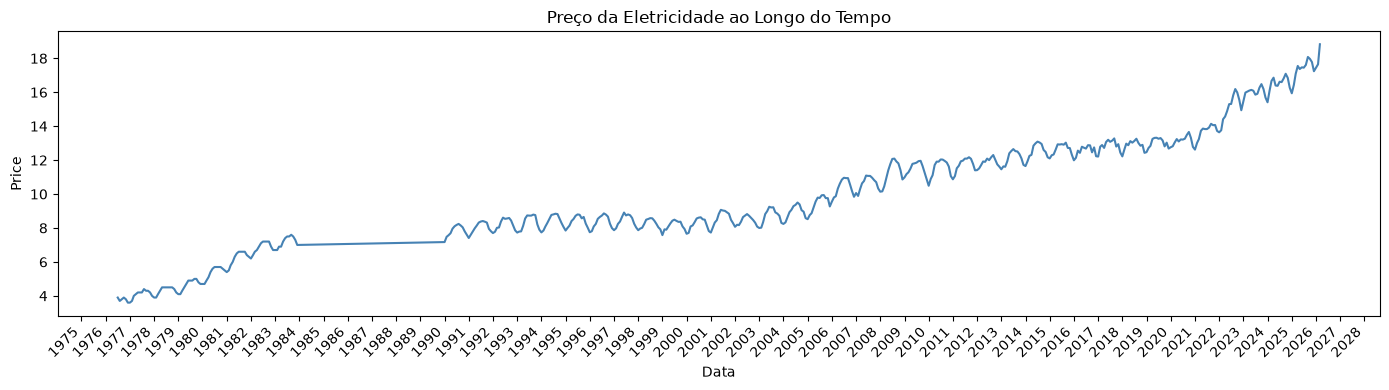

In [117]:
# Preço da Eletricidade
plt.figure(figsize=(14, 4))
plt.plot(df_final.index, df_final['Price'], color='steelblue')
plt.title('Preço da Eletricidade ao Longo do Tempo')
plt.ylabel('Price')
plt.xlabel('Data')

# Configurando o eixo X para colocar um marcador a cada ano
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
# Formatando o texto do marcador para exibir apenas o ano (YYYY)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Rotacionando para evitar sobreposição
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

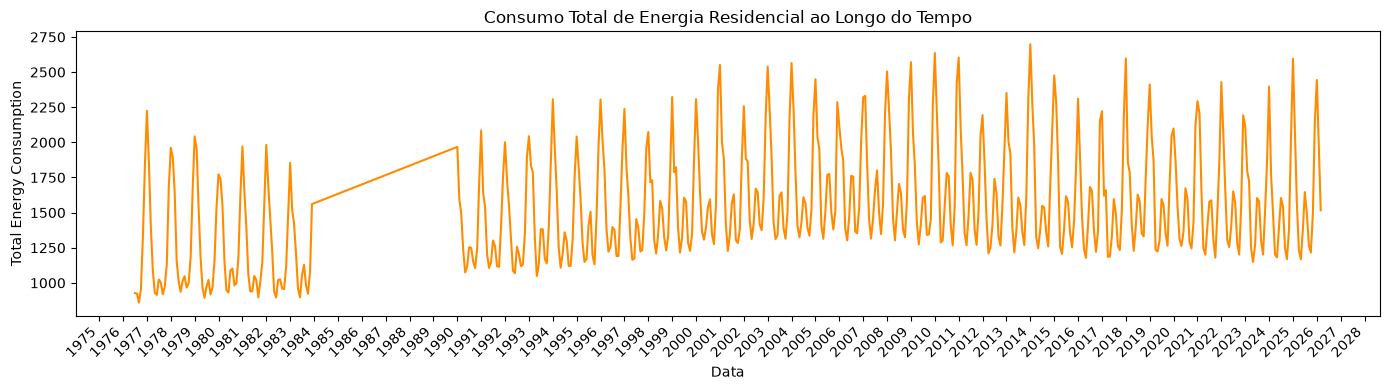

In [118]:
# Consumo Total de Energia Residencial
plt.figure(figsize=(14, 4))
plt.plot(df_final.index, df_final['Total Energy Consumption'], color='darkorange')
plt.title('Consumo Total de Energia Residencial ao Longo do Tempo')
plt.ylabel('Total Energy Consumption')
plt.xlabel('Data')

# Configurando o eixo X para colocar um marcador a cada ano
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
# Formatando o texto do marcador para exibir apenas o ano (YYYY)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Rotacionando para evitar sobreposição
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Tratando a inconsistência da década de 80

In [119]:
# O diff() calcula a diferença de tempo entre a linha atual e a anterior
diferenca_tempo = df_final.index.to_series().diff()

# Um mês normal tem entre 28 e 31 dias. Se a diferença for maior que 35 dias, achamos um buraco.
buracos = diferenca_tempo[diferenca_tempo.dt.days > 35]

print("Saltos temporais encontrados no dataset:")
print(buracos)

Saltos temporais encontrados no dataset:
Date
1990-01-01   2223 days
Name: Date, dtype: timedelta64[us]


Repare que de fato não há valores de consumo de energia para os anos do meio para o final de 1980

In [120]:
# Fatiando o dataframe no período suspeito (um pouco antes de sumir e um pouco depois de voltar)
df_suspeito = df_final['1984-01-01':'1990-12-31']

# Mostrando os últimos meses antes do salto
print("--- Antes da linha reta ---")
display(df_suspeito[['Price', 'Total Energy Consumption']].head())

# Mostrando os primeiros meses quando a reta termina
print("\n--- Depois da linha reta ---")
display(df_suspeito[['Price', 'Total Energy Consumption']].tail())

--- Antes da linha reta ---


,Price,Total Energy Consumption
Date,,
1990-01-01,7.17,1967.736
1990-02-01,7.48,1593.825
1990-03-01,7.57,1497.662
1990-04-01,7.69,1236.987
1990-05-01,7.96,1075.027



--- Depois da linha reta ---


,Price,Total Energy Consumption
Date,,
1990-08-01,8.24,1249.219
1990-09-01,8.15,1152.166
1990-10-01,8.04,1105.569
1990-11-01,7.80,1246.797
1990-12-01,7.61,1707.137


Portanto, precisamos excluí-los para continuar tratando os dados como uma série temporal.

In [121]:
# Filtra o dataset para manter apenas os dados a partir de 1º de janeiro de 1990
df_final = df_final.loc['1990-01-01':].copy()

# Verifica se sobrou algum salto temporal inexplicado
diferenca_tempo = df_final.index.to_series().diff()
buracos_restantes = diferenca_tempo[diferenca_tempo.dt.days > 35]

print(f"Novo tamanho do dataset: {df_final.shape}")
print(f"Buracos restantes encontrados: {len(buracos_restantes)}")

Novo tamanho do dataset: (435, 22)
Buracos restantes encontrados: 0


In [122]:
df_final.head()

,Price,Total Energy Consumption,CDD East North Central,CDD East South Central,CDD Middle Atlantic,CDD Mountain,CDD New England,CDD Pacific,CDD South Atlantic,CDD United States,...,HDD East North Central,HDD East South Central,HDD Middle Atlantic,HDD Mountain,HDD New England,HDD Pacific,HDD South Atlantic,HDD United States,HDD West North Central,HDD West South Central
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-01,7.17,1967.736,0.0,15.0,0.0,0.0,0.0,9.0,51.0,14.0,...,985.0,612.0,917.0,923.0,1011.0,600.0,482.0,746.0,1040.0,431.0
1990-02-01,7.48,1593.825,0.0,13.0,0.0,0.0,0.0,5.0,53.0,14.0,...,933.0,437.0,856.0,824.0,988.0,587.0,366.0,672.0,986.0,317.0
1990-03-01,7.57,1497.662,2.0,24.0,0.0,12.0,0.0,8.0,61.0,20.0,...,754.0,382.0,759.0,626.0,877.0,442.0,308.0,552.0,770.0,253.0
1990-04-01,7.69,1236.987,0.0,17.0,0.0,45.0,0.0,24.0,63.0,28.0,...,485.0,234.0,482.0,382.0,580.0,267.0,183.0,339.0,484.0,94.0
1990-05-01,7.96,1075.027,22.0,109.0,7.0,84.0,0.0,31.0,183.0,83.0,...,301.0,85.0,283.0,283.0,365.0,230.0,63.0,202.0,272.0,18.0


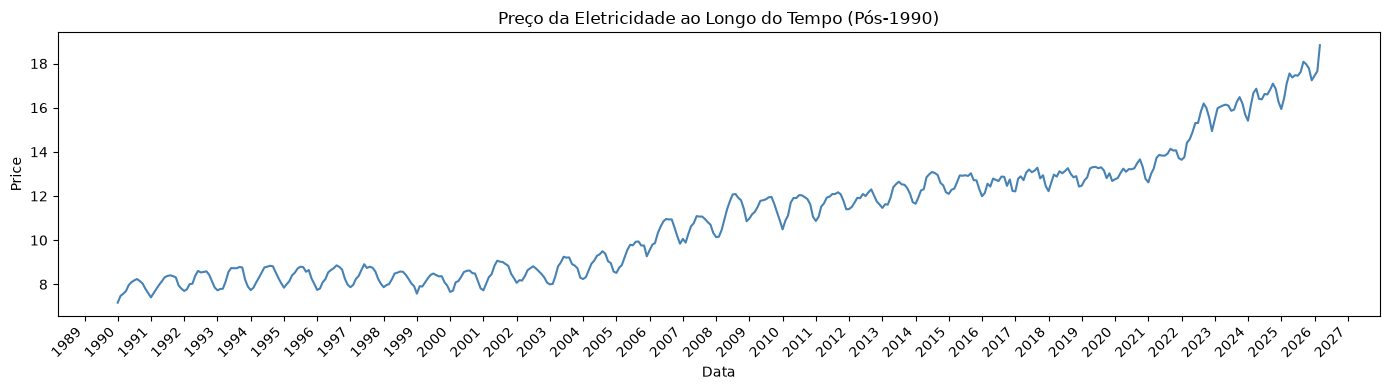

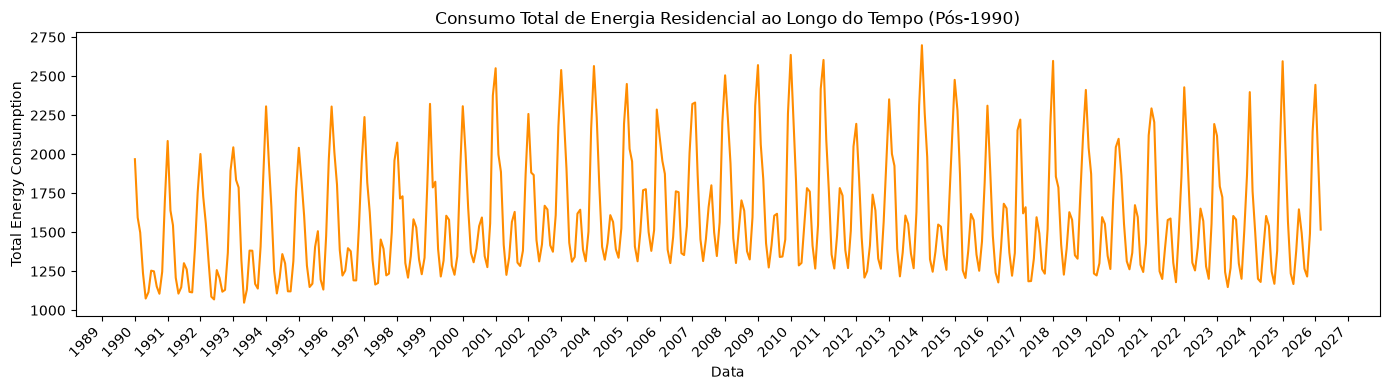

In [123]:
# Figura 1: Preço da Eletricidade (Série Limpa a partir de 1990)
plt.figure(figsize=(14, 4))
plt.plot(df_final.index, df_final['Price'], color='steelblue')
plt.title('Preço da Eletricidade ao Longo do Tempo (Pós-1990)')
plt.ylabel('Price')
plt.xlabel('Data')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Figura 2: Consumo Total de Energia Residencial (Série Limpa a partir de 1990)
plt.figure(figsize=(14, 4))
plt.plot(df_final.index, df_final['Total Energy Consumption'], color='darkorange')
plt.title('Consumo Total de Energia Residencial ao Longo do Tempo (Pós-1990)')
plt.ylabel('Total Energy Consumption')
plt.xlabel('Data')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Modelos de predição

Para tratar os dados como temporais, adicionamos duas features que capturam dependências temporais: 
- Previous Month: o valor de consumo de energia do mês anterior
- Month Previous Year: o valor de consumo de energia do mesmo mês no ano anterior

In [124]:
# Criando features de atraso (lags) para o alvo e para o preço
# Lag 1 = Mês anterior, Lag 12 = Mesmo mês no ano anterior
df_final['Previous_Month'] = df_final['Total Energy Consumption'].shift(1)
df_final['Month_Previous_Year'] = df_final['Total Energy Consumption'].shift(12)

# Criando features de mês para ajudar o modelo com a sazonalidade
df_final['Month'] = df_final.index.month

# Precisamos remover as linhas que ficam com valores NaN devido às novas features (por exemplo, o elemento de data mais antiga não 
# terá mês ou ano anterior)
df_ml = df_final.dropna().copy()

df_ml.head()

,Price,Total Energy Consumption,CDD East North Central,CDD East South Central,CDD Middle Atlantic,CDD Mountain,CDD New England,CDD Pacific,CDD South Atlantic,CDD United States,...,HDD Mountain,HDD New England,HDD Pacific,HDD South Atlantic,HDD United States,HDD West North Central,HDD West South Central,Previous_Month,Month_Previous_Year,Month
Date,,,,,,,,,,,,,,,,,,,,,
1991-01-01,7.41,2084.503,0.0,4.0,0.0,0.0,0.0,6.0,47.0,10.0,...,1024.0,1247.0,611.0,591.0,937.0,1474.0,656.0,1707.137,1967.736,1
1991-02-01,7.61,1639.052,0.0,4.0,0.0,8.0,0.0,10.0,30.0,9.0,...,636.0,945.0,373.0,447.0,650.0,912.0,351.0,2084.503,1593.825,2
1991-03-01,7.79,1544.592,1.0,21.0,0.0,2.0,0.0,7.0,56.0,20.0,...,724.0,838.0,588.0,335.0,584.0,766.0,222.0,1639.052,1497.662,3
1991-04-01,7.98,1207.913,3.0,53.0,0.0,22.0,0.0,14.0,106.0,41.0,...,484.0,492.0,376.0,134.0,306.0,386.0,56.0,1544.592,1236.987,4
1991-05-01,8.14,1106.455,128.0,221.0,73.0,69.0,28.0,22.0,264.0,142.0,...,269.0,159.0,280.0,16.0,114.0,131.0,3.0,1207.913,1075.027,5


In [125]:
len(df_ml)

423

### Random Forests - Temporal

Random Forest - RMSE: 58.98 | MAE: 48.65 | R²: 0.9727


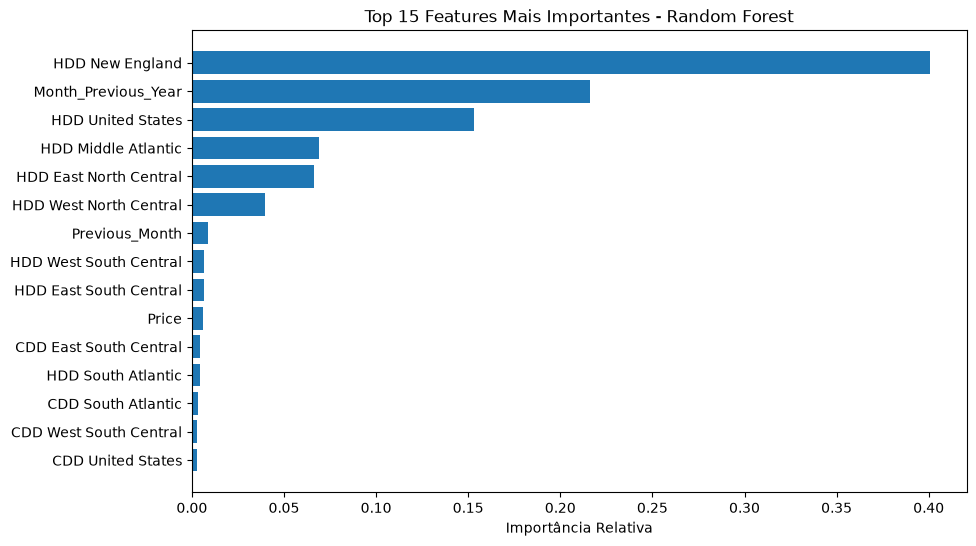

In [126]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # <-- r2_score importado aqui
import numpy as np
import matplotlib.pyplot as plt

# Separando X (features) e y (target)
target_col = 'Total Energy Consumption'
X = df_ml.drop(columns=[target_col])
y = df_ml[target_col]

# Divisão Treino/Teste sem embaralhar (shuffle=False), pois é uma série temporal
train_size = int(len(df_ml) * 0.8) # 80% treino, 20% teste
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Instanciando e treinando o Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Avaliação
y_pred = rf_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred) # <-- Calculando o R² aqui

# Print atualizado com as três métricas
print(f"Random Forest - RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}")

# Plot da Importância das Features
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-15:] # Pegando as 15 variáveis mais importantes

plt.figure(figsize=(10, 6))
plt.title("Top 15 Features Mais Importantes - Random Forest")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Importância Relativa")
plt.show()

In [127]:

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Adicionado para garantir que a métrica funcione no final

# 1. Definir o espaço de busca para Random Forest
param_dist_rf_time = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 'log2', None]
}

# 2. Definir o validador temporal
tscv = TimeSeriesSplit(n_splits=5)

# 3. Instanciar o modelo base
# n_jobs=-1 paraleliza a construção das árvores usando todos os núcleos do processador
rf_base_time = RandomForestRegressor(random_state=42, n_jobs=-1)

# 4. Configurar a Busca Aleatória
random_search_rf_time = RandomizedSearchCV(
    estimator=rf_base_time,
    param_distributions=param_dist_rf_time,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1, # Paraleliza a busca
    random_state=42,
    verbose=1
)

# 5. Executar a busca (Nomes corrigidos para X_train e y_train)
random_search_rf_time.fit(X_train, y_train)

print("Melhores Hiperparâmetros RF (Temporal):", random_search_rf_time.best_params_)
print(f"Melhor RMSE na Validação: {-random_search_rf_time.best_score_:.2f}")

# 6. Avaliando no conjunto de teste final (Nomes corrigidos para X_test e y_test)
melhor_rf_t = random_search_rf_time.best_estimator_
y_pred_rf_opt_t = melhor_rf_t.predict(X_test)
rmse_rf_opt_t = np.sqrt(mean_squared_error(y_test, y_pred_rf_opt_t))
print(f"RMSE no Teste com RF otimizado: {rmse_rf_opt_t:.2f}")
# Avaliando no conjunto de teste final
melhor_rf_t = random_search_rf_time.best_estimator_
y_pred_rf_opt_t = melhor_rf_t.predict(X_test)

rmse_rf_opt_t = np.sqrt(mean_squared_error(y_test, y_pred_rf_opt_t))
mae_rf_opt_t = mean_absolute_error(y_test, y_pred_rf_opt_t)
r2_rf_opt_t = r2_score(y_test, y_pred_rf_opt_t)

print(f"Random Forest Otimizado - RMSE: {rmse_rf_opt_t:.2f} | MAE: {mae_rf_opt_t:.2f} | R²: {r2_rf_opt_t:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Melhores Hiperparâmetros RF (Temporal): {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 283}
Melhor RMSE na Validação: 110.89
RMSE no Teste com RF otimizado: 65.59
Random Forest Otimizado - RMSE: 65.59 | MAE: 55.08 | R²: 0.9662


### Random Forest - Não Temporal

Random Forest (Sem Tempo) - RMSE: 105.80 | MAE: 80.81 | R²: 0.9328


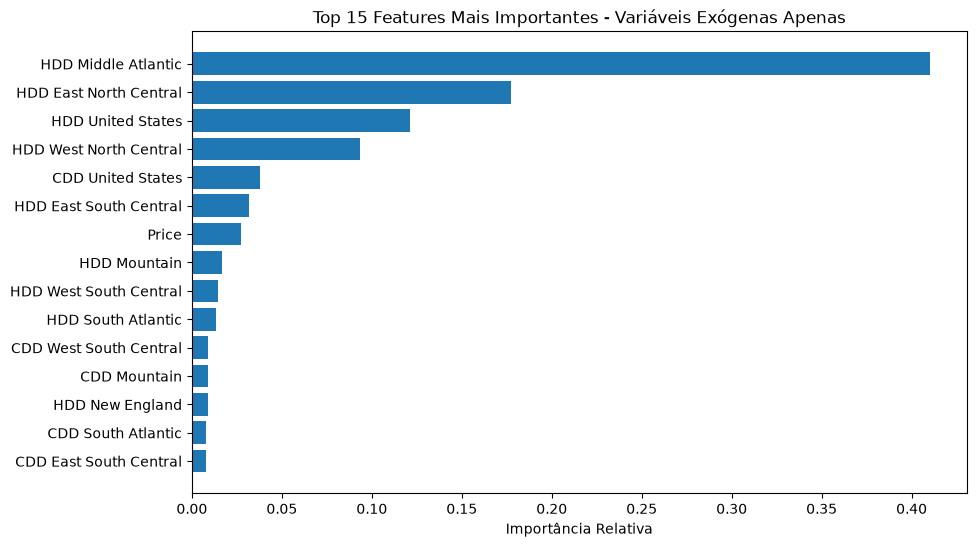

In [128]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # <-- r2_score adicionado
import matplotlib.pyplot as plt
import numpy as np

df_cross = df_final.copy()

# 1. Se a data for o índice, nós a removemos (reset_index com drop=True)
if df_cross.index.name == 'Date':
    df_cross = df_cross.reset_index(drop=True)
# Se a data ainda for uma coluna normal, nós a deletamos
elif 'Date' in df_cross.columns:
    df_cross = df_cross.drop(columns=['Date'])

# 2. Garantir que variáveis temporais (se criadas antes) sejam removidas
colunas_temporais = ['Previous_Month', 'Month_Previous_Year', 'Month']
df_cross = df_cross.drop(columns=[c for c in colunas_temporais if c in df_cross.columns])

# Remover eventuais valores nulos (NaN)
df_cross = df_cross.dropna()

# 3. Separar X (features) e y (target)
target_col = 'Total Energy Consumption'
X = df_cross.drop(columns=[target_col])
y = df_cross[target_col]

# 4. Divisão Treino/Teste COM embaralhamento (shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# 5. Instanciando e treinando o Random Forest
rf_model_cross = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_cross.fit(X_train, y_train)

# 6. Avaliação com R²
y_pred = rf_model_cross.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred) # <-- Cálculo do R² inserido aqui

# Print atualizado
print(f"Random Forest (Sem Tempo) - RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}")

# 7. Plot da Importância das Features
importances = rf_model_cross.feature_importances_
indices = np.argsort(importances)[-15:] # Top 15 variáveis

plt.figure(figsize=(10, 6))
plt.title("Top 15 Features Mais Importantes - Variáveis Exógenas Apenas")
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Importância Relativa")
plt.show()

In [129]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # <-- Importações corrigidas e adicionadas

# 1. A grade de busca pode ser a mesma
param_dist_rf_cross = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

# 2. Definir o validador padrão (K-Fold com embaralhamento)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Instanciar o modelo base
rf_base_cross = RandomForestRegressor(random_state=42, n_jobs=-1)

# 4. Configurar a Busca Aleatória
random_search_rf_cross = RandomizedSearchCV(
    estimator=rf_base_cross,
    param_distributions=param_dist_rf_cross,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=kf,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 5. Executar a busca (usando os dados não-temporais X_train e y_train)
random_search_rf_cross.fit(X_train, y_train)

print("Melhores Hiperparâmetros RF (Não-Temporal):", random_search_rf_cross.best_params_)
print(f"Melhor RMSE na Validação (Cross-Validation): {-random_search_rf_cross.best_score_:.2f}\n")

# 6. Avaliando no conjunto de teste final
melhor_rf_c = random_search_rf_cross.best_estimator_
y_pred_rf_opt_c = melhor_rf_c.predict(X_test)

# Calculando as três métricas
rmse_rf_opt_c = np.sqrt(mean_squared_error(y_test, y_pred_rf_opt_c))
mae_rf_opt_c = mean_absolute_error(y_test, y_pred_rf_opt_c) # <-- Calculando o MAE
r2_rf_opt_c = r2_score(y_test, y_pred_rf_opt_c) # <-- Calculando o R²

# Print final padronizado
print(f"Random Forest Otimizado (Sem Tempo) - RMSE: {rmse_rf_opt_c:.2f} | MAE: {mae_rf_opt_c:.2f} | R²: {r2_rf_opt_c:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Melhores Hiperparâmetros RF (Não-Temporal): {'max_depth': 13, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 104}
Melhor RMSE na Validação (Cross-Validation): 100.48

Random Forest Otimizado (Sem Tempo) - RMSE: 110.14 | MAE: 83.42 | R²: 0.9272


### XGBoost - Temporal

XGBoost (Temporal) - RMSE: 67.48 | MAE: 50.99 | R²: 0.9643


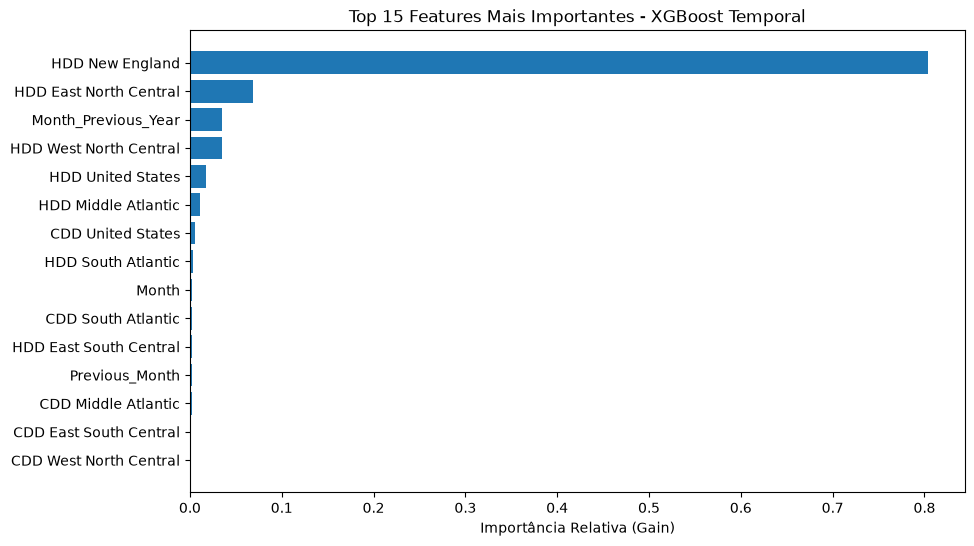

In [130]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # <-- r2_score importado aqui
import matplotlib.pyplot as plt

# 1. FORÇAR A CONVERSÃO: Aplica to_numeric em todas as colunas do df_ml.
# Tudo que for string será forçado a virar float. O que não puder virar float vira NaN.
df_ml = df_ml.apply(pd.to_numeric, errors='coerce')

# Preencher possíveis NaNs que a conversão forçada possa ter gerado
df_ml = df_ml.bfill()

# 2. Separar X (features) e y (target)
target_col = 'Total Energy Consumption'
X_time = df_ml.drop(columns=[target_col])
y_time = df_ml[target_col]

# 3. Divisão cronológica (Treino e Teste)
train_size = int(len(df_ml) * 0.8)
X_train_t, X_test_t = X_time.iloc[:train_size], X_time.iloc[train_size:]
y_train_t, y_test_t = y_time.iloc[:train_size], y_time.iloc[train_size:]

# 4. Instanciar o XGBoost
xgb_time_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    tree_method='hist',
    random_state=42
)

# 5. Treinamento
xgb_time_model.fit(X_train_t, y_train_t)

# 6. Avaliação (Agora com R²)
y_pred_t = xgb_time_model.predict(X_test_t)
rmse_t = np.sqrt(mean_squared_error(y_test_t, y_pred_t))
mae_t = mean_absolute_error(y_test_t, y_pred_t)
r2_t = r2_score(y_test_t, y_pred_t)

print(f"XGBoost (Temporal) - RMSE: {rmse_t:.2f} | MAE: {mae_t:.2f} | R²: {r2_t:.4f}")

# 7. Plot da Importância das Features (Estilo idêntico ao Random Forest)
importances = xgb_time_model.feature_importances_
indices = np.argsort(importances)[-15:] # Pegando as 15 variáveis mais importantes

plt.figure(figsize=(10, 6))
plt.title("Top 15 Features Mais Importantes - XGBoost Temporal")
plt.barh(range(len(indices)), importances[indices], align="center")
# Usamos X_time.columns para garantir que estamos pegando os nomes corretos deste dataset
plt.yticks(range(len(indices)), [X_time.columns[i] for i in indices])
plt.xlabel("Importância Relativa (Gain)")
plt.show()

In [131]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import xgboost as xgb
import numpy as np
from scipy.stats import uniform, randint

# 1. Definir a grade de busca (espaço de hiperparâmetros)
param_dist_time = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4), # Fração de amostras usadas por árvore
    'colsample_bytree': uniform(0.6, 0.4) # Fração de features usadas por árvore
}

# 2. Definir o validador temporal (ex: 5 splits cronológicos)
tscv = TimeSeriesSplit(n_splits=5)

# 3. Instanciar o modelo base
xgb_base_time = xgb.XGBRegressor(tree_method='hist', random_state=42)

# 4. Configurar a Busca Aleatória
# n_iter=20 significa que ele testará 20 combinações aleatórias.
# n_jobs=-1 usa todos os núcleos do seu processador para rodar em paralelo.
random_search_time = RandomizedSearchCV(
    estimator=xgb_base_time,
    param_distributions=param_dist_time,
    n_iter=20,
    scoring='neg_root_mean_squared_error', # Otimiza focando em diminuir o RMSE
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 5. Executar a busca (usando seus dados temporais)
# Assumindo que X_train_t e y_train_t estão na memória
random_search_time.fit(X_train_t, y_train_t)

print("Melhores Hiperparâmetros (Temporal):", random_search_time.best_params_)
print(f"Melhor RMSE na Validação: {-random_search_time.best_score_:.2f}")

# Avaliando no conjunto de teste final
melhor_modelo_t = random_search_time.best_estimator_
y_pred_opt_t = melhor_modelo_t.predict(X_test_t)
rmse_opt_t = np.sqrt(mean_squared_error(y_test_t, y_pred_opt_t))
print(f"RMSE no Teste com modelo otimizado: {rmse_opt_t:.2f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores Hiperparâmetros (Temporal): {'colsample_bytree': np.float64(0.8989280440549523), 'learning_rate': np.float64(0.11793842647781595), 'max_depth': 4, 'n_estimators': 266, 'subsample': np.float64(0.7123738038749523)}
Melhor RMSE na Validação: 108.51
RMSE no Teste com modelo otimizado: 57.56


### XGBoost - Não Temporal

XGBoost (Sem Tempo) - RMSE: 106.08 | MAE: 75.06 | R²: 0.9325


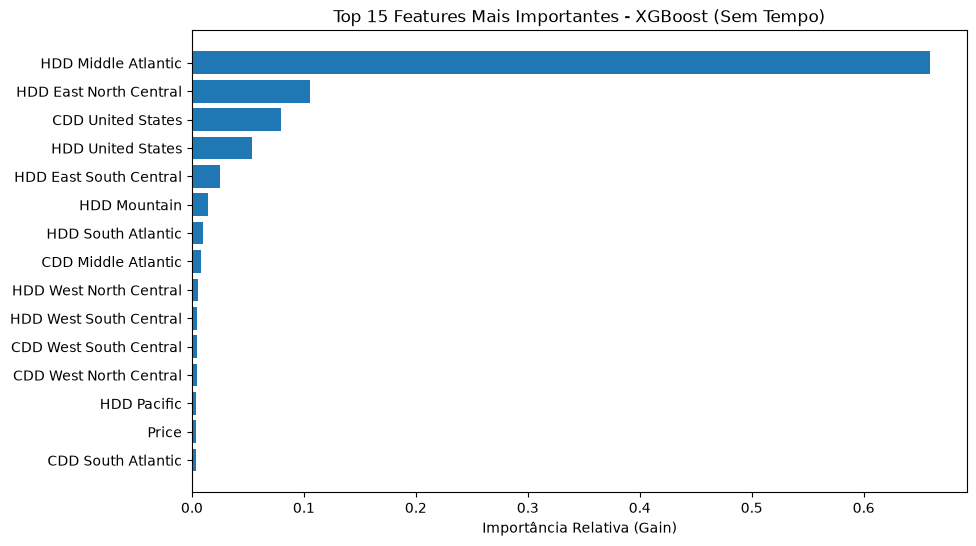

In [132]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # <-- r2_score importado aqui
import matplotlib.pyplot as plt

# 1. Criar uma base limpa a partir do df_final original
df_cross = df_final.copy()

# Se a data for o índice, nós a removemos
if df_cross.index.name == 'Date':
    df_cross = df_cross.reset_index(drop=True)
elif 'Date' in df_cross.columns:
    df_cross = df_cross.drop(columns=['Date'])

# 2. Remover vazamentos temporais (lags e mês, se existirem nessa cópia)
colunas_temporais = ['Month_Previous_Year', 'Previous_Month', 'Month']
df_cross = df_cross.drop(columns=[c for c in colunas_temporais if c in df_cross.columns])

# 3. FORÇAR A CONVERSÃO: O segredo para o XGBoost não falhar
df_cross = df_cross.apply(pd.to_numeric, errors='coerce')

# Remover eventuais linhas que tenham ficado com NaN após a limpeza e conversão
df_cross = df_cross.dropna()

# 4. Separar X (features) e y (target)
target_col = 'Total Energy Consumption'
X_cross = df_cross.drop(columns=[target_col])
y_cross = df_cross[target_col]

# 5. Divisão aleatória COM shuffle (crucial para dados não-temporais)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cross, y_cross, test_size=0.2, random_state=42, shuffle=True
)

# 6. Instanciar o XGBoost
xgb_cross_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    tree_method='hist',
    random_state=42
)

# 7. Treinamento
xgb_cross_model.fit(X_train_c, y_train_c)

# 8. Avaliação (Agora com R²)
y_pred_c = xgb_cross_model.predict(X_test_c)
rmse_c = np.sqrt(mean_squared_error(y_test_c, y_pred_c))
mae_c = mean_absolute_error(y_test_c, y_pred_c)
r2_c = r2_score(y_test_c, y_pred_c) # <-- Calculando o R² aqui

print(f"XGBoost (Sem Tempo) - RMSE: {rmse_c:.2f} | MAE: {mae_c:.2f} | R²: {r2_c:.4f}")

# 9. Plot da Importância das Features (Estilo idêntico)
importances = xgb_cross_model.feature_importances_
indices = np.argsort(importances)[-15:] # Pegando as 15 variáveis mais importantes

plt.figure(figsize=(10, 6))
plt.title("Top 15 Features Mais Importantes - XGBoost (Sem Tempo)")
plt.barh(range(len(indices)), importances[indices], align="center")
# Usamos X_cross.columns para garantir que estamos pegando os nomes corretos
plt.yticks(range(len(indices)), [X_cross.columns[i] for i in indices])
plt.xlabel("Importância Relativa (Gain)")
plt.show()

In [133]:
from sklearn.model_selection import RandomizedSearchCV, KFold

# 1. Definir a grade de busca (podemos usar a mesma do exemplo anterior)
param_dist_cross = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

# 2. Definir o validador padrão (K-Fold com embaralhamento)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Instanciar o modelo base
xgb_base_cross = xgb.XGBRegressor(tree_method='hist', random_state=42)

# 4. Configurar a Busca Aleatória
random_search_cross = RandomizedSearchCV(
    estimator=xgb_base_cross,
    param_distributions=param_dist_cross,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=kf,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 5. Executar a busca (usando seus dados não-temporais)
# Assumindo que X_train_c e y_train_c estão na memória
random_search_cross.fit(X_train_c, y_train_c)

print("Melhores Hiperparâmetros (Não-Temporal):", random_search_cross.best_params_)
print(f"Melhor RMSE na Validação: {-random_search_cross.best_score_:.2f}")

# Avaliando no conjunto de teste final
melhor_modelo_c = random_search_cross.best_estimator_
y_pred_opt_c = melhor_modelo_c.predict(X_test_c)
rmse_opt_c = np.sqrt(mean_squared_error(y_test_c, y_pred_opt_c))
print(f"RMSE no Teste com modelo otimizado: {rmse_opt_c:.2f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Melhores Hiperparâmetros (Não-Temporal): {'colsample_bytree': np.float64(0.8989280440549523), 'learning_rate': np.float64(0.11793842647781595), 'max_depth': 4, 'n_estimators': 266, 'subsample': np.float64(0.7123738038749523)}
Melhor RMSE na Validação: 87.26
RMSE no Teste com modelo otimizado: 88.95
